# Clasificación multiclase

En el cuaderno anterior vimos clasificación **binaria**, que funciona cuando las observaciones pertenecen a una de dos clases. Cuando hay más de dos, se necesita un algoritmo **multiclase**.

La clasificación multiclase puede verse como una combinación de varios clasificadores binarios. Hay dos formas de abordarlo:

**Uno frente al resto (OVR)** — un clasificador por cada clase posible, con resultado positivo cuando la predicción es *esa* clase y negativo para cualquier otra. Con cuatro formas (cuadrado, círculo, triángulo, hexágono) harían falta **4** clasificadores:
- cuadrado o no · círculo o no · triángulo o no · hexágono o no

**Uno frente a uno (OVO)** — un clasificador por cada *par* de clases. Con cuatro formas harían falta **6**:
- cuadrado/círculo · cuadrado/triángulo · cuadrado/hexágono · círculo/triángulo · círculo/hexágono · triángulo/hexágono

En ambos enfoques, el modelo general combina las predicciones individuales para decidir la clase final.

Por suerte, en scikit-learn implementar clasificación multiclase no es más complejo que la binaria: la mayoría de estimadores la soportan de forma implícita, abstrayendo OVR u OVO.

> **Cita**: el dataset de pingüinos es un subconjunto de datos recopilados por la [Dra. Kristen Gorman](https://www.uaf.edu/cfos/people/faculty/detail/kristen-gorman.php) y la [Palmer Station, Antarctica LTER](https://lternet.edu/site/palmer-antarctica-lter).

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

penguins = pd.read_csv('../datasets/penguins.csv')

# Muestra aleatoria de 10 observaciones
penguins.sample(10, random_state=0)

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
141,40.6,17.2,187.0,3475.0,0
6,38.9,17.8,181.0,3625.0,0
60,35.7,16.9,185.0,3150.0,0
249,46.9,14.6,222.0,4875.0,1
54,34.5,18.1,187.0,2900.0,0
312,47.6,18.3,195.0,3850.0,2
126,38.8,17.6,191.0,3275.0,0
215,54.3,15.7,231.0,5650.0,1
252,48.5,15.0,219.0,4850.0,1
100,35.0,17.9,192.0,3725.0,0


Las columnas son:

- **CulmenLength**: largo del culmen (pico) en mm.
- **CulmenDepth**: profundidad del culmen en mm.
- **FlipperLength**: largo de la aleta en mm.
- **BodyMass**: masa corporal en gramos.
- **Species**: entero que representa la especie.

**Species** es el label. Hay tres especies posibles, codificadas 0, 1 y 2:

In [2]:
penguin_classes = ['Adelie', 'Gentoo', 'Chinstrap']

muestra = penguins.sample(10, random_state=0)
for _, row in muestra.iterrows():
    especie = int(row.iloc[4])
    print(f'[{row.iloc[0]}, {row.iloc[1]}, {row.iloc[2]}, {row.iloc[3]}, {especie}] → {penguin_classes[especie]}')

[40.6, 17.2, 187.0, 3475.0, 0] → Adelie
[38.9, 17.8, 181.0, 3625.0, 0] → Adelie
[35.7, 16.9, 185.0, 3150.0, 0] → Adelie
[46.9, 14.6, 222.0, 4875.0, 1] → Gentoo
[34.5, 18.1, 187.0, 2900.0, 0] → Adelie
[47.6, 18.3, 195.0, 3850.0, 2] → Chinstrap
[38.8, 17.6, 191.0, 3275.0, 0] → Adelie
[54.3, 15.7, 231.0, 5650.0, 1] → Gentoo
[48.5, 15.0, 219.0, 4850.0, 1] → Gentoo
[35.0, 17.9, 192.0, 3725.0, 0] → Adelie


## Valores faltantes

Antes de entrenar, comprobamos si faltan datos.

In [3]:
print('Nulos por columna:')
print(penguins.isnull().sum())

Nulos por columna:
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64


In [4]:
# Filas que contienen algún nulo
penguins[penguins.isnull().any(axis=1)]

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
3,NaN,NaN,NaN,NaN,0
271,NaN,NaN,NaN,NaN,1


Hay **dos filas sin ningún valor de feature** (`NaN` = *not a number*). No sirven para entrenar, así que se descartan.

In [5]:
antes = len(penguins)
penguins = penguins.dropna()
print(f'{antes} → {len(penguins)} filas (se descartaron {antes - len(penguins)})')
print('\nNulos restantes:', penguins.isnull().sum().sum())

344 → 342 filas (se descartaron 2)

Nulos restantes: 0


## Explorar la relación entre features y label

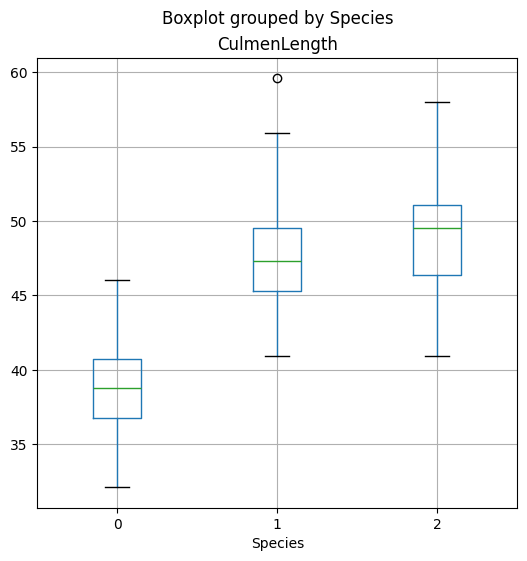

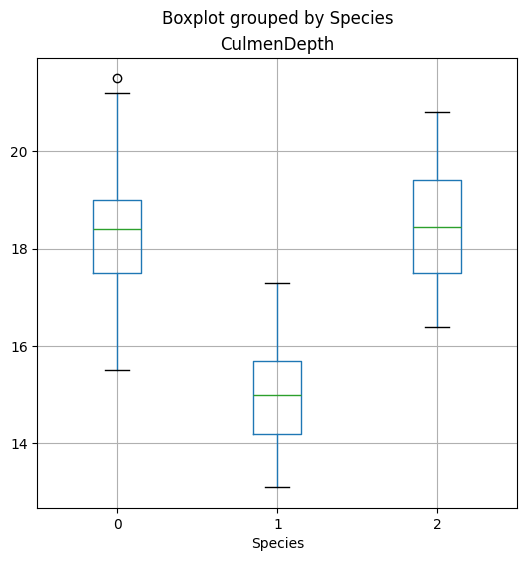

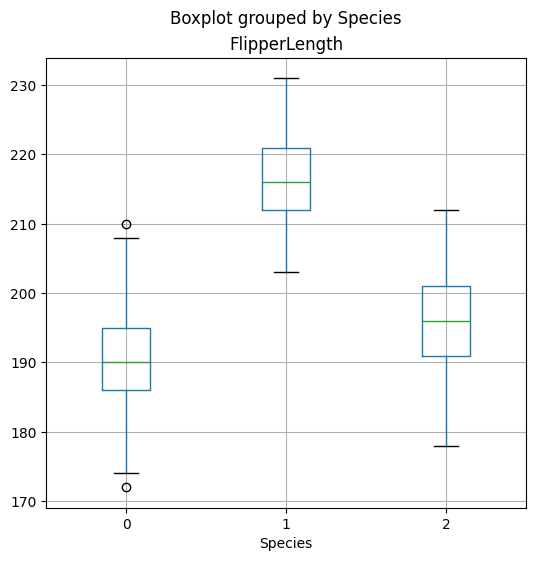

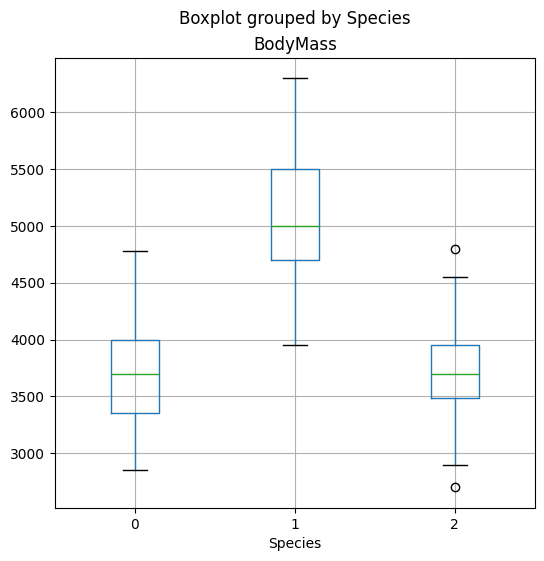

In [6]:
penguin_features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
penguin_label = 'Species'

for col in penguin_features:
    penguins.boxplot(column=col, by=penguin_label, figsize=(6,6))
    plt.title(col)
plt.show()

De los diagramas de caja se ve que las especies 0 y 2 (Adelie y Chinstrap) tienen perfiles parecidos en profundidad de culmen, largo de aleta y masa corporal — pero los Chinstrap tienden a tener el culmen más largo. La especie 1 (Gentoo) se diferencia con bastante claridad de las otras dos.

## Preparar los datos

Igual que en binaria: separar features y label, y dividir. Además aplicamos **estratificación** (`stratify`) al dividir, para mantener la proporción de cada especie en ambos subconjuntos.

In [7]:
from sklearn.model_selection import train_test_split

penguins_X, penguins_y = penguins[penguin_features].values, penguins[penguin_label].values

x_train, x_test, y_train, y_test = train_test_split(
    penguins_X, penguins_y, test_size=0.30, random_state=0, stratify=penguins_y)

print(f'Entrenamiento: {x_train.shape[0]} · Prueba: {x_test.shape[0]}')

Entrenamiento: 239 · Prueba: 103


## Entrenar un clasificador multiclase

La mayoría de algoritmos de clasificación de scikit-learn soportan multiclase de forma inherente. Probamos con regresión logística.

> **Nota de compatibilidad**: el ejercicio original pasa `multi_class='auto'` a `LogisticRegression`. Ese parámetro fue **eliminado** en scikit-learn 1.7 y hoy provoca un error. Se omite: el comportamiento multiclase es automático.

In [8]:
from sklearn.linear_model import LogisticRegression

reg = 0.1
multi_model = LogisticRegression(C=1/reg, solver='lbfgs', max_iter=10000).fit(x_train, y_train)
print(multi_model)

LogisticRegression(C=10.0, max_iter=10000)


In [9]:
penguin_predictions = multi_model.predict(x_test)
print('Labels predichos:', penguin_predictions[:15])
print('Labels reales   :', y_test[:15])

Labels predichos: [0 1 0 2 2 1 1 1 0 2 2 1 2 1 2]
Labels reales   : [0 1 2 2 2 1 1 1 0 2 2 1 2 1 2]


## Informe de clasificación

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, penguin_predictions, target_names=penguin_classes, digits=4))

              precision    recall  f1-score   support

      Adelie     0.9565    0.9778    0.9670        45
      Gentoo     1.0000    1.0000    1.0000        37
   Chinstrap     0.9500    0.9048    0.9268        21

    accuracy                         0.9709       103
   macro avg     0.9688    0.9608    0.9646       103
weighted avg     0.9708    0.9709    0.9707       103



Igual que en binaria, el informe trae precisión y recall **por clase**. Pero aquí, en vez de fijarnos en la clase positiva, necesitamos una métrica **global** (el promedio macro o el ponderado) para tener una idea del rendimiento sobre las tres clases.

Con resultados multiclase hay que especificar qué promedio usar:

- **macro**: promedia las métricas de cada clase dándoles el mismo peso, sin importar cuántos casos tenga cada una.
- **weighted**: pondera por el número de casos de cada clase.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Exactitud global :', accuracy_score(y_test, penguin_predictions))
print('Precisión (macro):', precision_score(y_test, penguin_predictions, average='macro'))
print('Recall (macro)   :', recall_score(y_test, penguin_predictions, average='macro'))
print('F1 (macro)       :', f1_score(y_test, penguin_predictions, average='macro'))

Exactitud global : 0.970873786407767
Precisión (macro): 0.9688405797101449
Recall (macro)   : 0.9608465608465608
F1 (macro)       : 0.96462074510855


## Matriz de confusión

Con varias clases, la matriz crece a una celda por cada combinación de clase real y predicha. La diagonal son los aciertos.

[[44  0  1]
 [ 0 37  0]
 [ 2  0 19]]


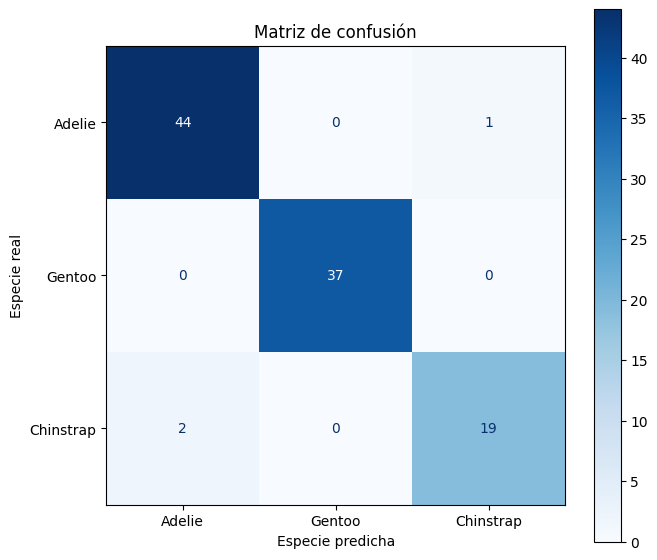

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mcm = confusion_matrix(y_test, penguin_predictions)
print(mcm)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(mcm, display_labels=penguin_classes).plot(ax=ax, cmap='Blues', values_format='d')
plt.xlabel('Especie predicha')
plt.ylabel('Especie real')
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

## Curvas ROC multiclase

Con más de dos clases **no se puede** dibujar una sola curva ROC. Lo que sí se puede es calcular las tasas de cada clase en una comparación *uno frente al resto* (OVR) y dibujar una curva por clase.

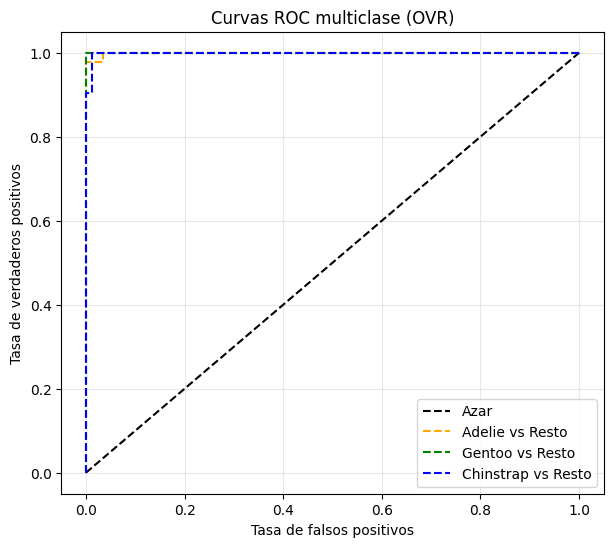

AUC promedio (OVR): 0.9993574254297553


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

penguin_prob = multi_model.predict_proba(x_test)

fig = plt.figure(figsize=(7,6))
plt.plot([0,1], [0,1], 'k--', label='Azar')

colores = ['orange', 'green', 'blue']
for i, clase in enumerate(penguin_classes):
    fpr, tpr, _ = roc_curve(y_test, penguin_prob[:,i], pos_label=i)
    plt.plot(fpr, tpr, linestyle='--', color=colores[i], label=f'{clase} vs Resto')

plt.title('Curvas ROC multiclase (OVR)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

auc = roc_auc_score(y_test, penguin_prob, multi_class='ovr')
print('AUC promedio (OVR):', auc)

## Curvas Precisión-Recall multiclase

> Esta sección **no está en el ejercicio original**; se añade porque la curva PR es uno de los entregables pedidos.

Mismo enfoque OVR: una curva por clase.

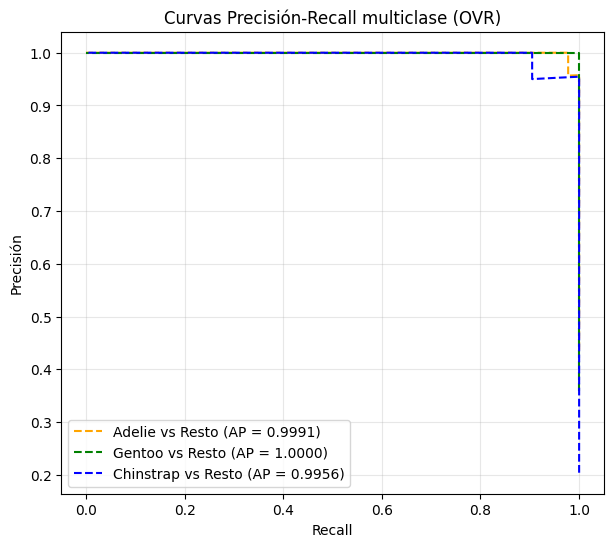

Precisión media (macro): 0.9982074325539371


In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig = plt.figure(figsize=(7,6))

for i, clase in enumerate(penguin_classes):
    y_binario = (y_test == i).astype(int)
    prec, rec, _ = precision_recall_curve(y_binario, penguin_prob[:,i])
    ap = average_precision_score(y_binario, penguin_prob[:,i])
    plt.plot(rec, prec, linestyle='--', color=colores[i], label=f'{clase} vs Resto (AP = {ap:.4f})')

plt.title('Curvas Precisión-Recall multiclase (OVR)')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

ap_macro = average_precision_score(
    np.eye(len(penguin_classes))[y_test], penguin_prob, average='macro')
print('Precisión media (macro):', ap_macro)

## Preprocesar en un pipeline y probar otro algoritmo

Igual que en binaria, podemos escalar las features antes de entrenar. Aprovechamos para probar una **máquina de vectores de soporte** (SVM).

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

feature_columns = [0,1,2,3]
feature_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessor = ColumnTransformer(transformers=[
    ('preprocess', feature_transformer, feature_columns)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clasificador', SVC(probability=True, random_state=0))
])

model_svm = pipeline.fit(x_train, y_train)
print(model_svm)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3])])),
                ('clasificador', SVC(probability=True, random_state=0))])


C:\Users\migue\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Evaluemos el nuevo modelo.

> **Corrección respecto al original**: el ejercicio de Microsoft vuelve a dibujar aquí la matriz `mcm` del modelo **anterior**, en vez de recalcularla para el nuevo. Es un error del cuaderno original — aquí se recalcula.

--- Regresión logística ---
Exactitud        : 0.9709
Precisión (macro): 0.9688
Recall (macro)   : 0.9608
F1 (macro)       : 0.9646
AUC (OVR)        : 0.9994



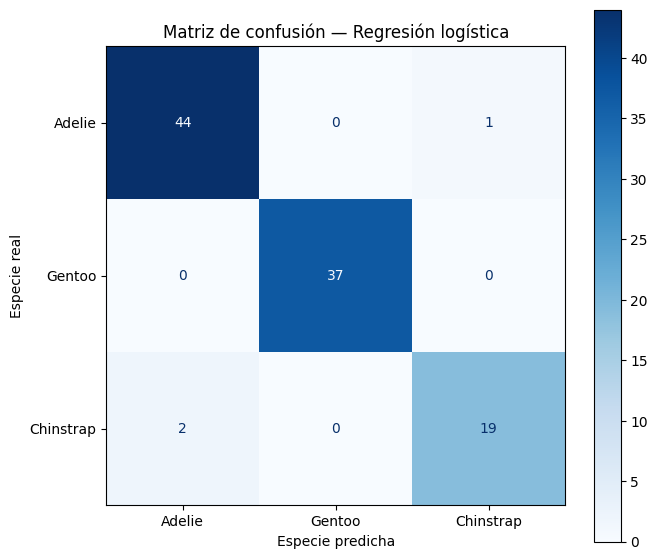

--- SVM + escalado ---
Exactitud        : 0.9806
Precisión (macro): 0.9767
Recall (macro)   : 0.9767
F1 (macro)       : 0.9767
AUC (OVR)        : 0.9990



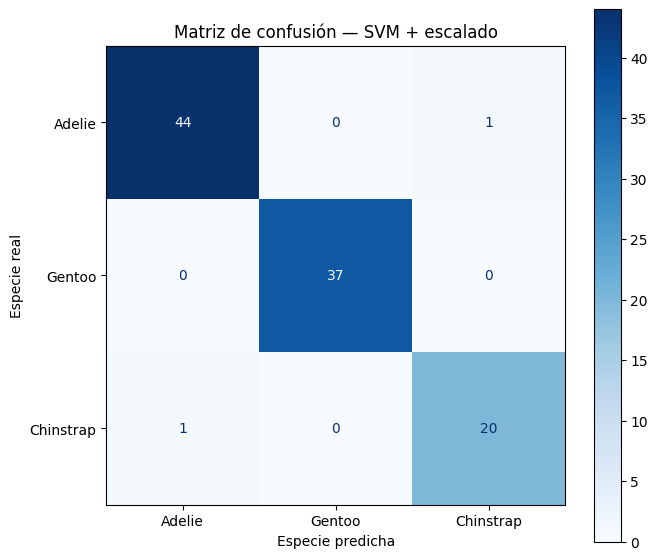

In [16]:
resultados = []

def evaluar_multiclase(model, nombre):
    preds = model.predict(x_test)
    prob = model.predict_proba(x_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec = recall_score(y_test, preds, average='macro')
    f1 = f1_score(y_test, preds, average='macro')
    auc = roc_auc_score(y_test, prob, multi_class='ovr')

    print(f'--- {nombre} ---')
    print(f'Exactitud        : {acc:.4f}')
    print(f'Precisión (macro): {prec:.4f}')
    print(f'Recall (macro)   : {rec:.4f}')
    print(f'F1 (macro)       : {f1:.4f}')
    print(f'AUC (OVR)        : {auc:.4f}\n')

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm, display_labels=penguin_classes).plot(ax=ax, cmap='Blues', values_format='d')
    plt.xlabel('Especie predicha'); plt.ylabel('Especie real')
    plt.title(f'Matriz de confusión — {nombre}')
    plt.tight_layout(); plt.show()

    resultados.append({'modelo': nombre, 'Exactitud': acc, 'Precisión': prec,
                       'Recall': rec, 'F1': f1, 'AUC': auc})

evaluar_multiclase(multi_model, 'Regresión logística')
evaluar_multiclase(model_svm, 'SVM + escalado')

## Comparativa

In [17]:
df_resultados = pd.DataFrame(resultados).sort_values('F1', ascending=False).reset_index(drop=True)
df_resultados.round(4)

,modelo,Exactitud,Precisión,Recall,F1,AUC
0,SVM + escalado,0.9806,0.9767,0.9767,0.9767,0.9990
1,Regresión logística,0.9709,0.9688,0.9608,0.9646,0.9994


## Guardar el modelo y usarlo con datos nuevos

> El `.pkl` no se versiona (ver `.gitignore`); se regenera ejecutando esta celda.

In [18]:
import joblib

modelos = {'Regresión logística': multi_model, 'SVM + escalado': model_svm}
mejor_nombre = df_resultados.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'Mejor modelo por F1: {mejor_nombre}')

filename = '../entregables/penguin-model.pkl'
joblib.dump(mejor_modelo, filename)
print(f'Guardado en: {filename}')

Mejor modelo por F1: SVM + escalado
Guardado en: ../entregables/penguin-model.pkl


In [19]:
loaded = joblib.load(filename)

# Un pingüino nuevo: [CulmenLength, CulmenDepth, FlipperLength, BodyMass]
x_new = np.array([[50.4, 15.3, 224, 5550]])
print('Observación nueva:', x_new[0])

pred = loaded.predict(x_new)[0]
prob = loaded.predict_proba(x_new)[0]
print(f'Clase predicha: {pred} → {penguin_classes[pred]}')
print('Probabilidades:', {c: round(p, 4) for c, p in zip(penguin_classes, prob)})

Observación nueva: [  50.4   15.3  224.  5550. ]
Clase predicha: 1 → Gentoo
Probabilidades: {'Adelie': np.float64(0.0077), 'Gentoo': np.float64(0.9849), 'Chinstrap': np.float64(0.0074)}


In [20]:
# También acepta un lote de observaciones
x_new = np.array([
    [49.5, 18.4, 195, 3600],
    [38.2, 20.1, 190, 3900]
])
print('Observaciones nuevas:')
print(x_new)

predictions = loaded.predict(x_new)
print()
for i, prediction in enumerate(predictions, 1):
    print(f'  Pingüino {i}: clase {prediction} → {penguin_classes[prediction]}')

Observaciones nuevas:
[[  49.5   18.4  195.  3600. ]
 [  38.2   20.1  190.  3900. ]]

  Pingüino 1: clase 2 → Chinstrap
  Pingüino 2: clase 0 → Adelie


## Resumen

La clasificación es una de las formas más comunes de machine learning. Con los principios de este cuaderno se pueden entrenar y evaluar modelos de clasificación con scikit-learn.

Lo que diferencia la multiclase de la binaria en la práctica:

- **Entrenar** es casi idéntico: scikit-learn abstrae OVR u OVO por dentro.
- **Evaluar** sí cambia: no hay una "clase positiva" única, así que las métricas globales necesitan un promedio (macro o ponderado), y las curvas ROC/PR se dibujan una por clase en modo OVR.